In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df=pd.read_csv("/content/Iris.csv")

In [ ]:
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Species']=le.fit_transform(df['Species'])
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,2
146,147,6.3,2.5,5.0,1.9,2
147,148,6.5,3.0,5.2,2.0,2
148,149,6.2,3.4,5.4,2.3,2


In [ ]:
y=df['Species']
print("y",y)

y 0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: Species, Length: 150, dtype: int64


In [ ]:
x=df.drop(columns=['Species'])
print("x",x)

x       Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0      1            5.1           3.5            1.4           0.2
1      2            4.9           3.0            1.4           0.2
2      3            4.7           3.2            1.3           0.2
3      4            4.6           3.1            1.5           0.2
4      5            5.0           3.6            1.4           0.2
..   ...            ...           ...            ...           ...
145  146            6.7           3.0            5.2           2.3
146  147            6.3           2.5            5.0           1.9
147  148            6.5           3.0            5.2           2.0
148  149            6.2           3.4            5.4           2.3
149  150            5.9           3.0            5.1           1.8

[150 rows x 5 columns]


In [ ]:
x=np.array(x)
y=np.array(y).reshape(-1,1)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42, stratify=y
)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
param_grid = {'n_neighbors': range(1, 21)}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=cv, scoring='accuracy')
grid.fit(X_train, y_train)

print("Best K:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

Best K: {'n_neighbors': 2}
Best CV Accuracy: 1.0


In [ ]:
best_knn = grid.best_estimator_

y_pred = best_knn.predict(X_test)


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix,f1_score

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Acurracy:",accuracy)

Acurracy: 1.0


In [ ]:
f1=f1_score(y_test, y_pred, zero_division=0, average='weighted')
print("F1 Score:",f1)

F1 Score: 1.0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
cm=confusion_matrix(y_test,y_pred)

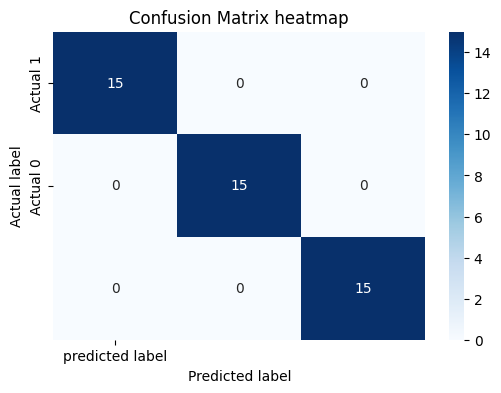

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['predicted label'], yticklabels=['Actual 1', 'Actual 0'])
plt.xlabel('Predicted label')
plt.ylabel('Actual label')
plt.title('Confusion Matrix heatmap')
plt.show()

In [ ]:
df=pd.read_csv("/content/boston.csv")

In [ ]:
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


In [ ]:
# Removed LabelEncoder for 'MEDV' as it's a continuous variable.
# from sklearn.preprocessing import LabelEncoder
# le=LabelEncoder()
# df['MEDV']=le.fit_transform(df['MEDV'])
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,137
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,113
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,196
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,193
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,203
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,121
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,104
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,136
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,117


In [ ]:
y=df['MEDV']
print("y",y)

y 0      137
1      113
2      196
3      193
4      203
      ... 
501    121
502    104
503    136
504    117
505     26
Name: MEDV, Length: 506, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

x = df.drop(columns=['MEDV'])
y = df['MEDV']

x=np.array(x)
y=np.array(y).reshape(-1,1)

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42 # Removed stratify=y
)

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

In [ ]:
knn_regressor = KNeighborsRegressor(n_neighbors=5) # You can adjust n_neighbors
knn_regressor.fit(X_train, y_train)

KNeighborsRegressor()

In [ ]:
y_pred_reg = knn_regressor.predict(X_test)

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold, KFold
from sklearn.neighbors import KNeighborsRegressor

param_grid = {'n_neighbors': range(1, 21)}
cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(KNeighborsRegressor(), param_grid, cv=cv, scoring='r2')
grid.fit(X_train, y_train)

print("Best K:", grid.best_params_)
print("Best CV R^2:", grid.best_score_)

y_pred = grid.best_estimator_.predict(X_test)


Best K: {'n_neighbors': 5}
Best CV R^2: 0.5522555880601253


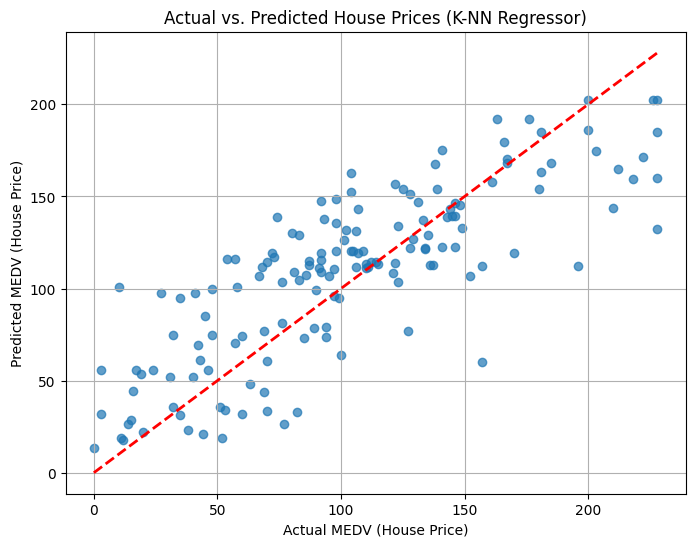

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual MEDV (House Price)')
plt.ylabel('Predicted MEDV (House Price)')
plt.title('Actual vs. Predicted House Prices (K-NN Regressor)')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

Mean Squared Error: 1128.20
R-squared: 0.64
